# Tutorial 01: Confusion Regime Mapping

**Workshop: ML for Galactic Binary Search & Parameter Estimation**

---

## Project Goal

**Map out where ML methods fail** — systematically characterize the model's performance across:
- Frequency separation (Δf)
- Signal-to-noise ratio (SNR)
- Number of sources (K)

This is directly relevant to LISA: understanding failure modes helps us know when to trust ML and when to fall back to traditional methods.

---

## Learning Outcomes (~30 min)

1. Design controlled experiments to probe model limits
2. Create diagnostic visualizations
3. Relate toy model results to LISA expectations
4. Identify extensions for your project work

---

In [1]:
# ================================================================
# Setup
# ================================================================
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm
import torch
import torch.nn.functional as F

from src.dataset import MultiSinusoidDataset
from src.model import SlotFlow

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [2]:
# ================================================================
# Load Model (reuse from Tutorial 00)
# ================================================================

config_path = "../pretrained_model/test_clariden/model_config.pt"
ckpt_dir = "../pretrained_model/test_clariden/checkpoints"

config = torch.load(config_path, map_location="cpu")

ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")]
ckpt_path = os.path.join(ckpt_dir, sorted(ckpt_files)[-1])
ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = {k.replace("model.", "").replace("_orig_mod.", ""): v 
              for k, v in ckpt["state_dict"].items()}

model = SlotFlow(
    hidden_dim=config["hidden_dim"],
    max_slots=config["max_slots"],
    flow_depth=config.get("flow_depth", 8),
    use_noise_encoder=config.get("use_noise_encoder", False),
)
model.load_state_dict(state_dict, strict=True)
model.to(device).eval()

# Key parameters
FREQ_RANGE = config["freq_range"]
T_LONG = config["tEnd_long"]
RAYLEIGH_LIMIT = 1.0 / T_LONG  # Hz

print(f"Model loaded. Rayleigh limit: {RAYLEIGH_LIMIT*1000:.2f} mHz")

/var/folders/sr/n2fcp1f90810jp4b_lrryl700000gn/T/ipykernel_25674/815581176.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  config = torch.load(config_path, map_location=

Model loaded. Rayleigh limit: 3.33 mHz


## 1. Frequency Separation Study

**Question**: At what Δf do two sources become indistinguishable?

The Rayleigh criterion says sources separated by less than 1/T should be unresolvable. Let's test this.

In [3]:
# ================================================================
# Generate Controlled 2-Source Signals
# ================================================================

def generate_two_source_signal(delta_f, noise_std=0.3, seed=None):
    """
    Generate a signal with exactly 2 sources separated by delta_f.
    
    Parameters
    ----------
    delta_f : float
        Frequency separation in Hz
    noise_std : float
        Noise level
    seed : int
        Random seed for reproducibility
    
    Returns
    -------
    x_long, x_short : tensors
        Signal streams
    true_params : tensor
        [A1, phi1, f1], [A2, phi2, f2]
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
    
    # Fixed center frequency
    f_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    f1 = f_center - delta_f / 2
    f2 = f_center + delta_f / 2
    
    # Random amplitudes and phases
    A1, A2 = np.random.uniform(0.8, 1.2, 2)
    phi1, phi2 = np.random.uniform(0, 2*np.pi, 2)
    
    # Time arrays
    t_long = torch.linspace(0, T_LONG, config["num_samples_long"])
    t_short = torch.linspace(0, config["tEnd_short"], config["num_samples_short"])
    
    # Generate signals
    s1_long = A1 * torch.sin(2*np.pi*f1*t_long + phi1)
    s2_long = A2 * torch.sin(2*np.pi*f2*t_long + phi2)
    s1_short = A1 * torch.sin(2*np.pi*f1*t_short + phi1)
    s2_short = A2 * torch.sin(2*np.pi*f2*t_short + phi2)
    
    # Combined + noise
    x_long = s1_long + s2_long + torch.randn_like(t_long) * noise_std
    x_short = s1_short + s2_short + torch.randn_like(t_short) * noise_std
    
    true_params = torch.tensor([[A1, phi1, f1], [A2, phi2, f2]])
    
    return x_long.float(), x_short.float(), true_params

# Test
x_l, x_s, params = generate_two_source_signal(delta_f=0.05, seed=42)
print(f"Generated signal with Δf = {params[1,2] - params[0,2]:.4f} Hz")
print(f"Frequencies: {params[0,2]:.4f}, {params[1,2]:.4f} Hz")

Generated signal with Δf = 0.0500 Hz
Frequencies: 2.7250, 2.7750 Hz


In [4]:
# ================================================================
# Sweep Frequency Separation (with Hungarian Matching)
# ================================================================

def hungarian_match(model, context, true_params, K_pred, freq_center):
    """
    Compute Hungarian matching between slots and true sources.
    Uses flow log-prob as cost (consistent with training).
    """
    true_k = len(true_params)
    
    # Convert true params to flow representation (ensure float32)
    if torch.is_tensor(true_params):
        tp = true_params.float()
    else:
        tp = torch.tensor(true_params, dtype=torch.float32)
    
    amp = tp[:, 0]
    phi = tp[:, 1]
    freq = tp[:, 2]
    true_params_4d = torch.stack(
        [amp, torch.cos(phi), torch.sin(phi), freq], dim=1
    ).to(device)
    
    # Apply normalization (same as training)
    gt_weighted = true_params_4d.clone()
    gt_weighted[:, 1:3] *= 2
    gt_weighted[:, 3] -= freq_center
    gt_weighted[:, 3] *= 3
    
    # Compute cost matrix
    ctx_exp = context.unsqueeze(0).expand(true_k, -1, -1)
    gt_exp = gt_weighted.unsqueeze(1).expand(-1, K_pred, -1)
    all_ctx = ctx_exp.reshape(-1, context.shape[-1])
    all_gt = gt_exp.reshape(-1, gt_weighted.shape[-1])
    
    logp = model.flow.log_prob(all_gt, context=all_ctx)
    cost = -logp.view(true_k, K_pred).detach().cpu().numpy()
    
    return linear_sum_assignment(cost)


@torch.no_grad()
def evaluate_separation(model, delta_f_values, n_trials=20, noise_std=0.3):
    """
    Evaluate K prediction accuracy as a function of frequency separation.
    Uses Hungarian matching for proper slot-to-source alignment.
    
    Returns dict with:
    - k_accuracy: fraction of trials where K=2 was correctly predicted
    - freq_error: mean absolute error in frequency estimates
    """
    results = {'delta_f': [], 'k_accuracy': [], 'k_mean': [], 'freq_error': []}
    freq_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    
    for delta_f in tqdm(delta_f_values, desc="Sweeping Δf"):
        k_correct = 0
        k_preds = []
        freq_errors = []
        
        for trial in range(n_trials):
            x_long, x_short, true_params = generate_two_source_signal(
                delta_f, noise_std=noise_std, seed=trial*1000 + int(delta_f*10000)
            )
            
            # Run model
            x_l = x_long.unsqueeze(0).to(device)
            x_s = x_short.unsqueeze(0).to(device)
            output = model(x_l, x_s)
            
            k_pred = output['K_pred'].item()
            k_preds.append(k_pred)
            
            if k_pred == 2:
                k_correct += 1
                
                context = output['context']
                
                # Hungarian matching
                row_ind, col_ind = hungarian_match(
                    model, context, true_params, k_pred, freq_center
                )
                
                # Compute frequency error for matched pairs
                errors = []
                for true_idx, slot_idx in zip(row_ind, col_ind):
                    samples = model.flow.sample(100, context=context[slot_idx:slot_idx+1])
                    f_pred = (samples[..., 3].mean().item() / 3.0) + freq_center
                    f_true = true_params[true_idx, 2].item()
                    errors.append(abs(f_pred - f_true))
                
                freq_errors.append(np.mean(errors))
        
        results['delta_f'].append(delta_f)
        results['k_accuracy'].append(k_correct / n_trials)
        results['k_mean'].append(np.mean(k_preds))
        results['freq_error'].append(np.mean(freq_errors) if freq_errors else np.nan)
    
    return {k: np.array(v) for k, v in results.items()}

# Run sweep
delta_f_values = np.array([0.005, 0.01, 0.015, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2])
results_df = evaluate_separation(model, delta_f_values, n_trials=30, noise_std=0.3)

print("\nSweep complete!")

Sweeping Δf: 100%|██████████| 10/10 [01:13<00:00,  7.31s/it]


Sweep complete!


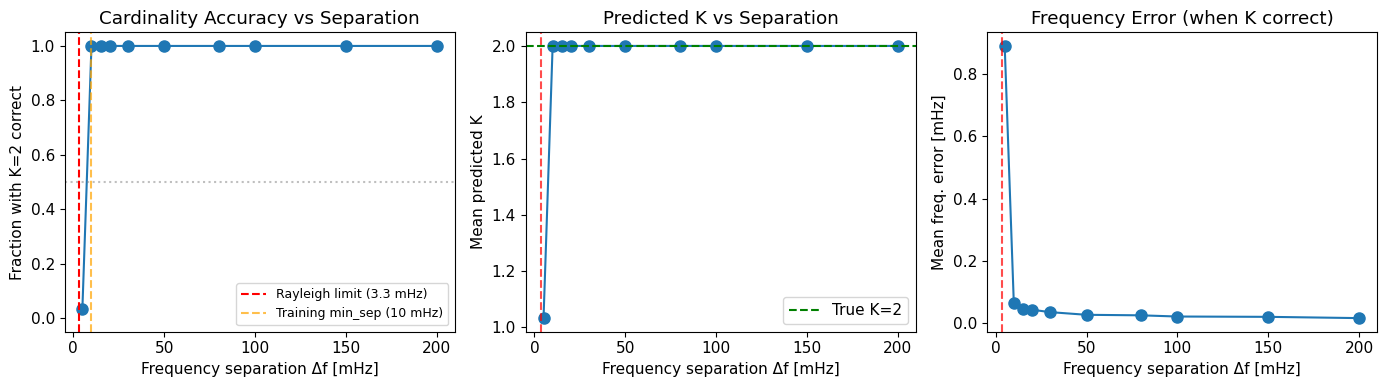


FREQUENCY SEPARATION FINDINGS
Rayleigh limit: 3.33 mHz
Training min_sep: 10 mHz
Empirical 50% accuracy limit: ~10.0 mHz
Ratio to Rayleigh: 3.0x


In [5]:
# ================================================================
# Visualize Frequency Separation Results
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. K accuracy vs Δf
ax = axes[0]
ax.plot(results_df['delta_f'] * 1000, results_df['k_accuracy'], 'o-', markersize=8)
ax.axvline(RAYLEIGH_LIMIT * 1000, color='red', ls='--', label=f'Rayleigh limit ({RAYLEIGH_LIMIT*1000:.1f} mHz)')
ax.axvline(10, color='orange', ls='--', alpha=0.7, label='Training min_sep (10 mHz)')
ax.axhline(0.5, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Frequency separation Δf [mHz]')
ax.set_ylabel('Fraction with K=2 correct')
ax.set_title('Cardinality Accuracy vs Separation')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)

# 2. Mean predicted K
ax = axes[1]
ax.plot(results_df['delta_f'] * 1000, results_df['k_mean'], 'o-', markersize=8)
ax.axhline(2, color='green', ls='--', label='True K=2')
ax.axvline(RAYLEIGH_LIMIT * 1000, color='red', ls='--', alpha=0.7)
ax.set_xlabel('Frequency separation Δf [mHz]')
ax.set_ylabel('Mean predicted K')
ax.set_title('Predicted K vs Separation')
ax.legend()

# 3. Frequency estimation error (when K=2 correct)
ax = axes[2]
valid = ~np.isnan(results_df['freq_error'])
ax.plot(results_df['delta_f'][valid] * 1000, results_df['freq_error'][valid] * 1000, 'o-', markersize=8)
ax.axvline(RAYLEIGH_LIMIT * 1000, color='red', ls='--', alpha=0.7)
ax.set_xlabel('Frequency separation Δf [mHz]')
ax.set_ylabel('Mean freq. error [mHz]')
ax.set_title('Frequency Error (when K correct)')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("FREQUENCY SEPARATION FINDINGS")
print("="*60)
print(f"Rayleigh limit: {RAYLEIGH_LIMIT*1000:.2f} mHz")
print(f"Training min_sep: 10 mHz")

# Find threshold
threshold_idx = np.where(results_df['k_accuracy'] > 0.5)[0]
if len(threshold_idx) > 0:
    empirical_limit = results_df['delta_f'][threshold_idx[0]]
    print(f"Empirical 50% accuracy limit: ~{empirical_limit*1000:.1f} mHz")
    print(f"Ratio to Rayleigh: {empirical_limit/RAYLEIGH_LIMIT:.1f}x")

## 2. SNR Study

**Question**: At what SNR does the model start failing?

In [6]:
# ================================================================
# Sweep Noise Level (inverse SNR)
# ================================================================

def compute_snr(amplitude, noise_std):
    """Compute approximate SNR for a sinusoid."""
    # SNR ≈ A²/(2σ²) for a sinusoid in Gaussian noise
    if noise_std < 1e-10:
        return np.inf
    return amplitude**2 / (2 * noise_std**2)

@torch.no_grad()
def evaluate_snr(model, noise_values, n_trials=30, delta_f=0.05):
    """
    Evaluate performance vs noise level (for 2-source signals).
    """
    results = {'noise_std': [], 'snr_db': [], 'k_accuracy': [], 'k_mean': []}
    
    for noise_std in tqdm(noise_values, desc="Sweeping noise"):
        k_correct = 0
        k_preds = []
        
        for trial in range(n_trials):
            x_long, x_short, true_params = generate_two_source_signal(
                delta_f, noise_std=noise_std, seed=trial*1000 + int(noise_std*1000)
            )
            
            x_l = x_long.unsqueeze(0).to(device)
            x_s = x_short.unsqueeze(0).to(device)
            output = model(x_l, x_s)
            
            k_pred = output['K_pred'].item()
            k_preds.append(k_pred)
            if k_pred == 2:
                k_correct += 1
        
        avg_amp = 1.0  # Approximate
        snr = compute_snr(avg_amp, noise_std)
        snr_db = 10 * np.log10(snr) if snr > 0 else -np.inf
        
        results['noise_std'].append(noise_std)
        results['snr_db'].append(snr_db)
        results['k_accuracy'].append(k_correct / n_trials)
        results['k_mean'].append(np.mean(k_preds))
    
    return {k: np.array(v) for k, v in results.items()}

# Run sweep (from low noise to high noise)
noise_values = np.array([0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0])
results_snr = evaluate_snr(model, noise_values, n_trials=30, delta_f=0.05)

print("\nSNR sweep complete!")

Sweeping noise: 100%|██████████| 9/9 [00:03<00:00,  2.68it/s]


SNR sweep complete!


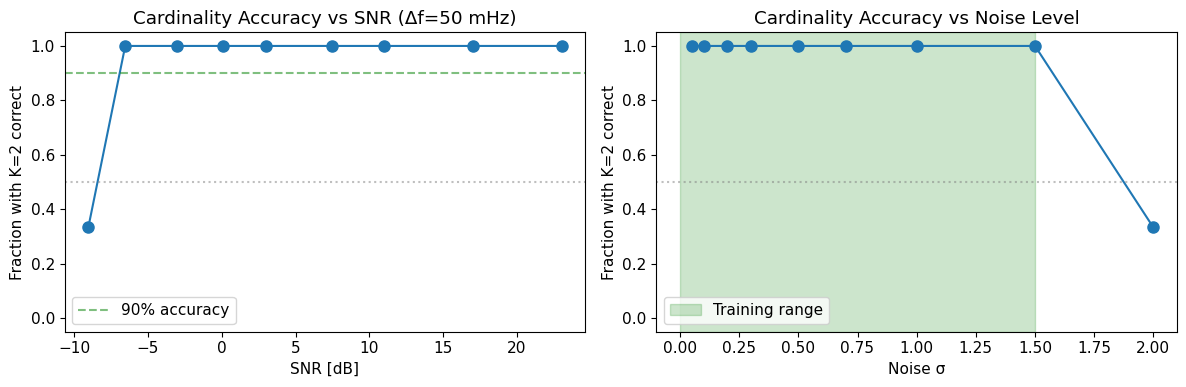


SNR FINDINGS
50% accuracy threshold: ~-9.0 dB (σ ≈ 2.00)
Training noise range: σ ∈ [0, 1.5]


In [7]:
# ================================================================
# Visualize SNR Results
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. K accuracy vs SNR
ax = axes[0]
ax.plot(results_snr['snr_db'], results_snr['k_accuracy'], 'o-', markersize=8)
ax.axhline(0.5, color='gray', ls=':', alpha=0.5)
ax.axhline(0.9, color='green', ls='--', alpha=0.5, label='90% accuracy')
ax.set_xlabel('SNR [dB]')
ax.set_ylabel('Fraction with K=2 correct')
ax.set_title('Cardinality Accuracy vs SNR (Δf=50 mHz)')
ax.legend()
ax.set_ylim(-0.05, 1.05)

# 2. K accuracy vs noise_std (training scale)
ax = axes[1]
ax.plot(results_snr['noise_std'], results_snr['k_accuracy'], 'o-', markersize=8)
ax.axvspan(0, 1.5, alpha=0.2, color='green', label='Training range')
ax.axhline(0.5, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Noise σ')
ax.set_ylabel('Fraction with K=2 correct')
ax.set_title('Cardinality Accuracy vs Noise Level')
ax.legend()
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

# Find SNR threshold
print("\n" + "="*60)
print("SNR FINDINGS")
print("="*60)
threshold_idx = np.where(results_snr['k_accuracy'] < 0.5)[0]
if len(threshold_idx) > 0:
    idx = threshold_idx[0]
    print(f"50% accuracy threshold: ~{results_snr['snr_db'][idx]:.1f} dB (σ ≈ {results_snr['noise_std'][idx]:.2f})")
print(f"Training noise range: σ ∈ [0, 1.5]")

## 3. Number of Sources (K) Study

**Question**: Does accuracy degrade as K increases?

In [8]:
# ================================================================
# Evaluate Performance vs K
# ================================================================

@torch.no_grad()
def evaluate_vs_k(model, config, k_values, n_trials=50):
    """
    Evaluate cardinality accuracy for different true K values.
    """
    results = {'k_true': [], 'k_accuracy': [], 'k_mean': [], 'k_std': []}
    
    for k_true in tqdm(k_values, desc="Sweeping K"):
        # Create dataset with fixed K
        test_set = MultiSinusoidDataset(
            set_size=n_trials,
            num_samples_long=config["num_samples_long"],
            tEnd_long=config["tEnd_long"],
            num_samples_short=config["num_samples_short"],
            tEnd_short=config["tEnd_short"],
            max_components=config["max_slots"],
            freq_range=config["freq_range"],
            amp_range=config["amp_range"],
            noise_std=config["noise_std"],
            min_freq_sep=0.01,
            seed=k_true * 1000,
            mode="inference",
            num_comp=k_true,  # Fixed K
        )
        
        k_preds = []
        for idx in range(n_trials):
            sample = test_set[idx]
            x_long, x_short = sample[0], sample[1]
            
            x_l = x_long.unsqueeze(0).to(device)
            x_s = x_short.unsqueeze(0).to(device)
            output = model(x_l, x_s)
            
            k_preds.append(output['K_pred'].item())
        
        k_preds = np.array(k_preds)
        results['k_true'].append(k_true)
        results['k_accuracy'].append(np.mean(k_preds == k_true))
        results['k_mean'].append(np.mean(k_preds))
        results['k_std'].append(np.std(k_preds))
    
    return {k: np.array(v) for k, v in results.items()}

# Run sweep
k_values = list(range(1, config["max_slots"] + 1))
results_k = evaluate_vs_k(model, config, k_values, n_trials=50)

print("\nK sweep complete!")

Sweeping K: 100%|██████████| 10/10 [00:07<00:00,  1.36it/s]


K sweep complete!


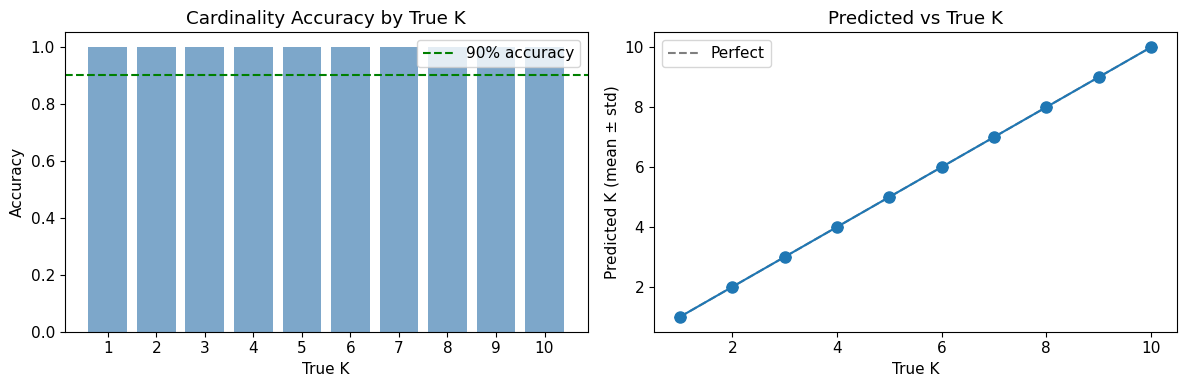


K-DEPENDENCY FINDINGS
All K values have >90% accuracy!


In [9]:
# ================================================================
# Visualize K Results
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Accuracy vs K
ax = axes[0]
ax.bar(results_k['k_true'], results_k['k_accuracy'], color='steelblue', alpha=0.7)
ax.axhline(0.9, color='green', ls='--', label='90% accuracy')
ax.set_xlabel('True K')
ax.set_ylabel('Accuracy')
ax.set_title('Cardinality Accuracy by True K')
ax.set_xticks(results_k['k_true'])
ax.legend()
ax.set_ylim(0, 1.05)

# 2. Predicted vs True K
ax = axes[1]
ax.errorbar(results_k['k_true'], results_k['k_mean'], yerr=results_k['k_std'],
            fmt='o-', capsize=4, markersize=8)
ax.plot([1, 10], [1, 10], 'k--', alpha=0.5, label='Perfect')
ax.set_xlabel('True K')
ax.set_ylabel('Predicted K (mean ± std)')
ax.set_title('Predicted vs True K')
ax.legend()
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0.5, 10.5)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("K-DEPENDENCY FINDINGS")
print("="*60)
low_acc = results_k['k_true'][results_k['k_accuracy'] < 0.9]
if len(low_acc) > 0:
    print(f"K values with <90% accuracy: {low_acc}")
else:
    print("All K values have >90% accuracy!")

## 4. Combined View: Confusion Map

Let's create a 2D map of accuracy vs (Δf, SNR).

In [10]:
# ================================================================
# 2D Confusion Map: Δf vs Noise
# ================================================================

@torch.no_grad()
def create_confusion_map(model, delta_f_values, noise_values, n_trials=15):
    """
    Create 2D accuracy map over (Δf, noise) space.
    """
    accuracy_map = np.zeros((len(noise_values), len(delta_f_values)))
    
    total = len(noise_values) * len(delta_f_values)
    with tqdm(total=total, desc="Building map") as pbar:
        for i, noise_std in enumerate(noise_values):
            for j, delta_f in enumerate(delta_f_values):
                k_correct = 0
                for trial in range(n_trials):
                    x_long, x_short, _ = generate_two_source_signal(
                        delta_f, noise_std=noise_std, 
                        seed=trial + i*1000 + j*100
                    )
                    
                    x_l = x_long.unsqueeze(0).to(device)
                    x_s = x_short.unsqueeze(0).to(device)
                    output = model(x_l, x_s)
                    
                    if output['K_pred'].item() == 2:
                        k_correct += 1
                
                accuracy_map[i, j] = k_correct / n_trials
                pbar.update(1)
    
    return accuracy_map

# Create coarser grid for speed
delta_f_grid = np.array([0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15])
noise_grid = np.array([0.1, 0.3, 0.5, 0.7, 1.0, 1.5])

confusion_map = create_confusion_map(model, delta_f_grid, noise_grid, n_trials=20)

Building map: 100%|██████████| 48/48 [00:12<00:00,  3.90it/s]


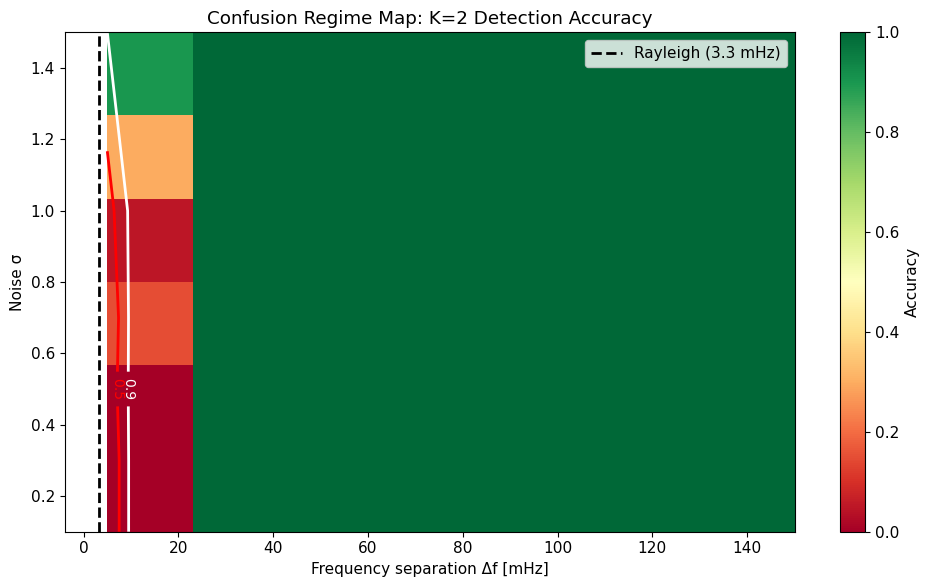


CONFUSION MAP INTERPRETATION

GREEN region: Model reliably detects 2 sources
YELLOW region: Marginal performance (50-90% accuracy)
RED region: Model fails (often predicts K=1)

The 50% contour line shows the empirical "confusion limit".



In [11]:
# ================================================================
# Visualize Confusion Map
# ================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Plot heatmap
im = ax.imshow(confusion_map, aspect='auto', origin='lower', 
               extent=[delta_f_grid[0]*1000, delta_f_grid[-1]*1000, 
                       noise_grid[0], noise_grid[-1]],
               cmap='RdYlGn', vmin=0, vmax=1)

# Add contour lines
X, Y = np.meshgrid(delta_f_grid * 1000, noise_grid)
cs = ax.contour(X, Y, confusion_map, levels=[0.5, 0.9], colors=['red', 'white'], linewidths=2)
ax.clabel(cs, inline=True, fontsize=10, fmt='%.1f')

# Mark Rayleigh limit
ax.axvline(RAYLEIGH_LIMIT * 1000, color='black', ls='--', lw=2, label=f'Rayleigh ({RAYLEIGH_LIMIT*1000:.1f} mHz)')

ax.set_xlabel('Frequency separation Δf [mHz]')
ax.set_ylabel('Noise σ')
ax.set_title('Confusion Regime Map: K=2 Detection Accuracy')
ax.legend(loc='upper right')

cbar = plt.colorbar(im, ax=ax, label='Accuracy')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CONFUSION MAP INTERPRETATION")
print("="*60)
print("""
GREEN region: Model reliably detects 2 sources
YELLOW region: Marginal performance (50-90% accuracy)
RED region: Model fails (often predicts K=1)

The 50% contour line shows the empirical "confusion limit".
""")

## 5. Translation to LISA

How do these findings translate to real LISA observations?

In [12]:
# ================================================================
# LISA Context
# ================================================================

print("="*70)
print("TRANSLATING TO LISA")
print("="*70)
print("""
SLOTFLOW TOY MODEL:
───────────────────
• T_obs = 300 s → Rayleigh limit = 3.3 mHz
• Empirical confusion limit: ~{:.1f}x Rayleigh
• Training min_sep = 10 mHz (~3x Rayleigh)

LISA (4-year mission):
──────────────────────
• T_obs = 4 years → Rayleigh limit = 8 nHz (!)
• If same 3x factor applies → confusion limit ~24 nHz
• Typical GB separation: varies widely, but many at ~μHz level

KEY INSIGHT:
────────────
The ~3x Rayleigh factor may be architecture-dependent, not fundamental.
With 4 years of data, LISA has far better intrinsic resolution.

OPEN QUESTIONS FOR YOUR PROJECT:
─────────────────────────────────
1. Is the 3x factor fundamental or can it be improved?
2. How does the confusion limit scale with K?
3. What happens with realistic TDI response?
4. Can we predict when the model will fail?
""".format(results_df['delta_f'][np.where(results_df['k_accuracy'] > 0.5)[0][0]] / RAYLEIGH_LIMIT 
           if len(np.where(results_df['k_accuracy'] > 0.5)[0]) > 0 else 0))

TRANSLATING TO LISA

SLOTFLOW TOY MODEL:
───────────────────
• T_obs = 300 s → Rayleigh limit = 3.3 mHz
• Empirical confusion limit: ~3.0x Rayleigh
• Training min_sep = 10 mHz (~3x Rayleigh)

LISA (4-year mission):
──────────────────────
• T_obs = 4 years → Rayleigh limit = 8 nHz (!)
• If same 3x factor applies → confusion limit ~24 nHz
• Typical GB separation: varies widely, but many at ~μHz level

KEY INSIGHT:
────────────
The ~3x Rayleigh factor may be architecture-dependent, not fundamental.
With 4 years of data, LISA has far better intrinsic resolution.

OPEN QUESTIONS FOR YOUR PROJECT:
─────────────────────────────────
1. Is the 3x factor fundamental or can it be improved?
2. How does the confusion limit scale with K?
3. What happens with realistic TDI response?
4. Can we predict when the model will fail?



---

## Project Extensions

**Ideas to continue this work:**

1. **Finer-grained map**: Increase resolution of the confusion map

2. **K > 2 confusion**: How does the map change with 3, 4, 5 sources?

3. **Asymmetric amplitudes**: Does a bright + faint source pair behave differently?

4. **Uncertainty quantification**: Can we use K-probability entropy to predict failures?

5. **Comparison with theory**: Compare empirical limits to Fisher matrix predictions

---

In [13]:
# ================================================================
# YOUR TURN: Extend the Analysis
# ================================================================

# Example: Test asymmetric amplitude case
# Modify generate_two_source_signal to have A1 >> A2

# TODO: Implement your extension here
# 
# Ideas:
# 1. def generate_asymmetric_signal(delta_f, amp_ratio=0.3, ...):
#        # One source has amp_ratio times the amplitude of the other
# 
# 2. def evaluate_with_uncertainty(model, ...):
#        # Return K-probability entropy as "confidence" measure
#
# 3. def compare_to_fisher(delta_f, noise_std, T_obs):
#        # Compute theoretical frequency precision from Fisher matrix